# Cora smoke test/training for your `adv_vgae.VGAE`

This notebook uses **your code as-is**:

- imports `VGAE`, `sample_vgae_negatives`, and `DEVICE` from `adv_vgae.py`
- does **not** define a replacement VGAE class
- does **not** add KL divergence
- calls your `model.fit(...)`
- converts Cora citation edges into `[src, dst, rel]` triples with `rel = 0`

This is intended as a fast debugging dataset before returning to Wikidata.


In [123]:
from pathlib import Path
import importlib
import random
import sys
from dataclasses import dataclass

import torch
import torch.nn.functional as F

try:
    import numpy as np
except ModuleNotFoundError:
    np = None
    print("NumPy not installed; continuing without it.")

# If this notebook is in the same folder as adv_vgae.py and rgcn_model.py,
# Path.cwd() should work. Otherwise set MODEL_DIR manually below.
#MODEL_DIR = Path.cwd().resolve()

# Manual fallback: uncomment and edit if needed.
MODEL_DIR = Path("/Users/adamabramowitz/Desktop/Everything_Coding/Math290/290-Final-Project/Detective_R-GCN/model").resolve()

if not (MODEL_DIR / "rgcn_model.py").exists():
    raise FileNotFoundError(f"Could not find rgcn_model.py in {MODEL_DIR}")

if not (MODEL_DIR / "adv_vgae.py").exists():
    raise FileNotFoundError(f"Could not find adv_vgae.py in {MODEL_DIR}")

if str(MODEL_DIR) not in sys.path:
    sys.path.insert(0, str(MODEL_DIR))

print("MODEL_DIR:", MODEL_DIR)
print("Found rgcn_model.py:", (MODEL_DIR / "rgcn_model.py").exists())
print("Found adv_vgae.py:", (MODEL_DIR / "adv_vgae.py").exists())


MODEL_DIR: /Users/adamabramowitz/Desktop/Everything_Coding/Math290/290-Final-Project/Detective_R-GCN/model
Found rgcn_model.py: True
Found adv_vgae.py: True


In [124]:
# Import YOUR code, not a replacement class.
import adv_vgae
adv_vgae = importlib.reload(adv_vgae)

VGAE = adv_vgae.VGAE
sample_vgae_negatives = adv_vgae.sample_vgae_negatives
DEVICE = adv_vgae.DEVICE

print("Imported adv_vgae from:", adv_vgae.__file__)
print("DEVICE:", DEVICE)
print("VGAE class:", VGAE)


Imported adv_vgae from: /Users/adamabramowitz/Desktop/Everything_Coding/Math290/290-Final-Project/Detective_R-GCN/model/adv_vgae.py
DEVICE: mps
VGAE class: <class 'adv_vgae.VGAE'>


In [125]:
# Load Cora through PyTorch Geometric.
# If this import fails, install PyG in your active environment.
try:
    from torch_geometric.datasets import Planetoid
except ModuleNotFoundError as e:
    raise ModuleNotFoundError(
        "torch_geometric is not installed in this Python environment. "
        "Install PyTorch Geometric, then rerun this notebook."
    ) from e


In [126]:
@dataclass
class SimpleRelationalGraph:
    name: str
    num_nodes: int
    num_relations: int
    train_edges: torch.Tensor
    val_edges: torch.Tensor
    test_edges: torch.Tensor
    node_features: torch.Tensor | None = None
    node_labels: torch.Tensor | None = None


def load_planetoid_as_relational_graph(
    name="Cora",
    root=None,
    val_ratio=0.05,
    test_ratio=0.10,
    seed=42,
    make_undirected=True,
):
    # Load Cora/Citeseer/PubMed and convert citation edges [src, dst]
    # into relational triples [src, dst, rel] with rel = 0.
    if root is None:
        root = str(MODEL_DIR / "data" / "planetoid")

    dataset = Planetoid(root=f"{root}/{name}", name=name)
    data = dataset[0]

    edge_pairs = data.edge_index.t().contiguous()  # [E, 2]

    if make_undirected:
        rev = edge_pairs[:, [1, 0]]
        edge_pairs = torch.cat([edge_pairs, rev], dim=0)
        edge_pairs = torch.unique(edge_pairs, dim=0)

    # Convert to [src, dst, rel], with one relation type for all citation edges.
    rel = torch.zeros(edge_pairs.size(0), 1, dtype=torch.long)
    edges = torch.cat([edge_pairs, rel], dim=1)
    edges = torch.unique(edges, dim=0)

    # Shuffle/split edges for link prediction.
    gen = torch.Generator()
    gen.manual_seed(seed)
    perm = torch.randperm(len(edges), generator=gen)
    edges = edges[perm]

    n_total = len(edges)
    n_test = int(test_ratio * n_total)
    n_val = int(val_ratio * n_total)
    n_train = n_total - n_val - n_test

    train_edges = edges[:n_train]
    val_edges = edges[n_train:n_train + n_val]
    test_edges = edges[n_train + n_val:]

    return SimpleRelationalGraph(
        name=name,
        num_nodes=data.num_nodes,
        num_relations=1,
        train_edges=train_edges.long(),
        val_edges=val_edges.long(),
        test_edges=test_edges.long(),
        node_features=data.x.float(),
        node_labels=data.y.long(),


    )


SEED = 42
random.seed(SEED)
if np is not None:
    np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

cora_graph = load_planetoid_as_relational_graph("Cora", seed=SEED, make_undirected=True)

print(f"Loaded graph: {cora_graph.name}")
print(f"Nodes: {cora_graph.num_nodes:,}")
print(f"Relations: {cora_graph.num_relations:,}")
print(f"Train edges: {len(cora_graph.train_edges):,}")
print(f"Val edges: {len(cora_graph.val_edges):,}")
print(f"Test edges: {len(cora_graph.test_edges):,}")
print(f"Node features: {cora_graph.node_features.shape if cora_graph.node_features is not None else None}")


Processing...
/Users/adamabramowitz/anaconda3/envs/Math290/lib/python3.13/site-packages/torch_geometric/io/planetoid.py:107: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  out = pickle.load(f, encoding='latin1')
/Users/adamabramowitz/anaconda3/envs/Math290/lib/python3.13/site-packages/torch_geometric/io/planetoid.py:107: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  out = pickle.load(f, encoding='latin1')
/Users/adamabramowitz/anaconda3/envs/Math290/lib/python3.13/site-packages/torch_geometric/io/planetoid.py:107: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  out = pickle.lo

Loaded graph: Cora
Nodes: 2,708
Relations: 1
Train edges: 8,974
Val edges: 527
Test edges: 1,055
Node features: torch.Size([2708, 1433])


Done!


In [127]:
# Config: small values for fast testing.
HIDDEN_DIM = 32
LATENT_DIM = 16
EPOCHS = 500
BATCH_SIZE = -1
NEG_RATIO = 1
LR = 1e-3
WEIGHT_DECAY = 1e-5

config = {
    "hidden_dim": HIDDEN_DIM,
    "latent_dim": LATENT_DIM,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "neg_ratio": NEG_RATIO,
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,
    "device": str(DEVICE),
}
config


{'hidden_dim': 32,
 'latent_dim': 16,
 'epochs': 500,
 'batch_size': -1,
 'neg_ratio': 1,
 'lr': 0.001,
 'weight_decay': 1e-05,
 'device': 'mps'}

In [128]:
# Initialize YOUR VGAE.
# Since Cora has node features, we pass feat_dim.
feat_dim = cora_graph.node_features.shape[1]

model = VGAE(
    num_nodes=cora_graph.num_nodes,
    hidden_dim=HIDDEN_DIM,
    num_relations=cora_graph.num_relations,  # 1 for Cora
    latent_dim=LATENT_DIM,
    feat_dim=feat_dim,
).to(DEVICE)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")


Model parameters: 115,821


In [129]:
# Train using YOUR model.fit exactly.
# Your fit currently trains with BCE only, so this is GAE-style testing.
history = model.fit(
    graph=cora_graph,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    neg_ratio=NEG_RATIO,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

print("Training finished.")
print("Number of recorded batch losses:", len(history["loss"]))
print("First loss:", history["loss"][0] if history["loss"] else None)
print("Last loss:", history["loss"][-1] if history["loss"] else None)


100%|██████████| 500/500 [00:32<00:00, 15.24it/s]

Training finished.
Number of recorded batch losses: 500
First loss: 0.9327495694160461
Last loss: 0.32527145743370056


In [130]:
model.eval()

train_edges = cora_graph.train_edges.to(DEVICE)
edge_index = train_edges[:, :2].t().contiguous()
edge_type = train_edges[:, 2]
node_features = (
    cora_graph.node_features.to(DEVICE)
    if cora_graph.node_features is not None
    else None
)
with torch.no_grad():
    z, mu, log_sig = model(
        edge_index,
        edge_type,
        node_features=node_features,
        num_nodes=cora_graph.num_nodes,
    )

z_cpu = z.detach().cpu()
#mu_cpu = mu.detach().cpu()
##log_sig_cpu = log_sig.detach().cpu()

latent_path = MODEL_DIR / "latent_data.pt"

torch.save(
    {
        "z": z_cpu,
        # "mu": mu_cpu,
        # "log_sig": log_sig_cpu,
        "train_edges": cora_graph.train_edges.cpu(),
        "val_edges": cora_graph.val_edges.cpu(),
        "test_edges": cora_graph.test_edges.cpu(),
        "node_features": (
            cora_graph.node_features.cpu()
            if cora_graph.node_features is not None
            else None
        ),
        "num_nodes": cora_graph.num_nodes,
        "num_relations": cora_graph.num_relations,
        "graph_name": cora_graph.name,
    },
    latent_path,
)

print(f"Saved final latents to {latent_path}")
print("z:", z_cpu.shape)
# print("mu:", mu_cpu.shape)
# print("log_sig:", log_sig_cpu.shape)


Saved final latents to /Users/adamabramowitz/Desktop/Everything_Coding/Math290/290-Final-Project/Detective_R-GCN/model/latent_data.pt
z: torch.Size([2708, 16])


z mean: 0.12334150075912476
z std: 1.7324376106262207
latents_2d range: [-8.095479 -4.822397] [6.719654 4.857851]


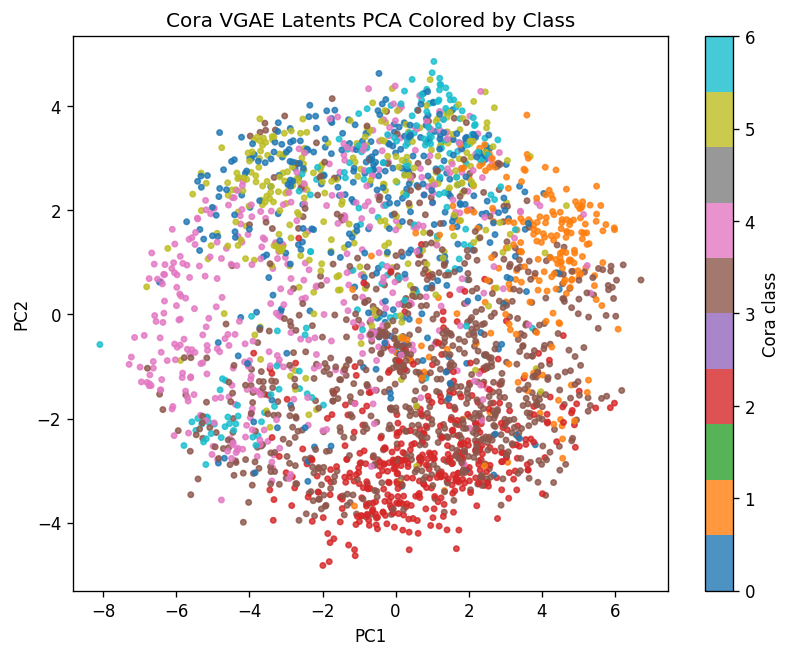

In [131]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

latents = z_cpu.numpy()
latents_2d = PCA(n_components=2).fit_transform(latents)

print("z mean:", z_cpu.mean().item())
print("z std:", z_cpu.std().item())
print("latents_2d range:", latents_2d.min(axis=0), latents_2d.max(axis=0))

labels = cora_graph.node_labels.cpu().numpy()

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    latents_2d[:, 0],
    latents_2d[:, 1],
    c=labels,
    s=10,
    alpha=0.8,
    cmap="tab10",
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Cora VGAE Latents PCA Colored by Class")
plt.colorbar(scatter, label="Cora class")
plt.show()

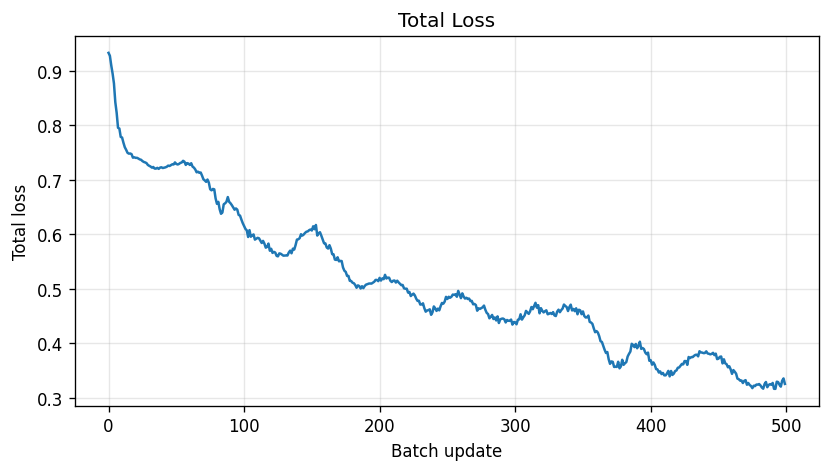

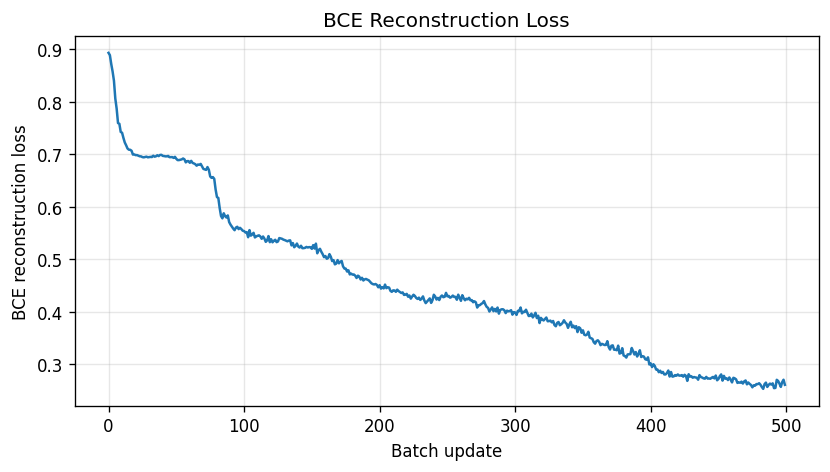

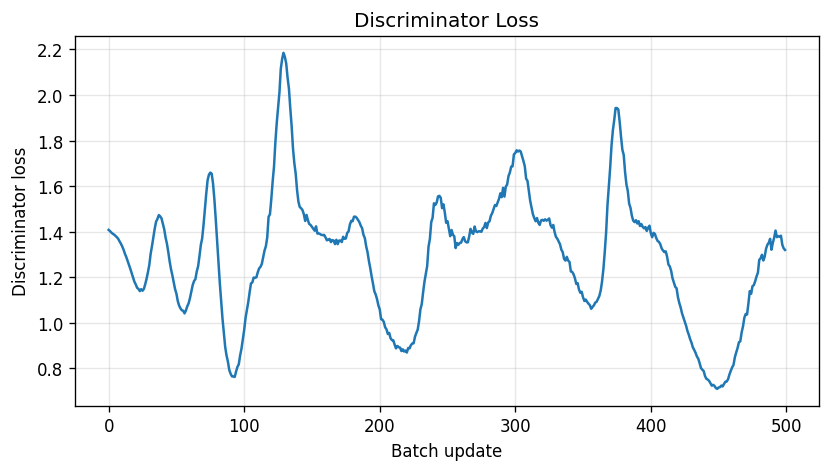

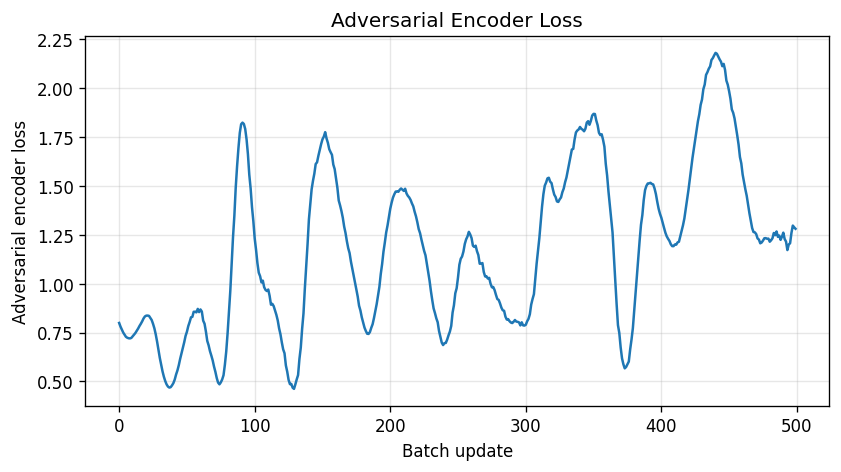

In [132]:
# ============================================================
# Separate training curves
# ============================================================

plt.figure(figsize=(8, 4))
plt.plot(history["loss"])
plt.xlabel("Batch update")
plt.ylabel("Total loss")
plt.title("Total Loss")
plt.grid(True, alpha=0.3)
plt.show()

if "bce_loss" in history:
    plt.figure(figsize=(8, 4))
    plt.plot(history["bce_loss"])
    plt.xlabel("Batch update")
    plt.ylabel("BCE reconstruction loss")
    plt.title("BCE Reconstruction Loss")
    plt.grid(True, alpha=0.3)
    plt.show()

if "disc_loss" in history:
    plt.figure(figsize=(8, 4))
    plt.plot(history["disc_loss"])
    plt.xlabel("Batch update")
    plt.ylabel("Discriminator loss")
    plt.title("Discriminator Loss")
    plt.grid(True, alpha=0.3)
    plt.show()

if "adv_loss" in history:
    plt.figure(figsize=(8, 4))
    plt.plot(history["adv_loss"])
    plt.xlabel("Batch update")
    plt.ylabel("Adversarial encoder loss")
    plt.title("Adversarial Encoder Loss")
    plt.grid(True, alpha=0.3)
    plt.show()

In [133]:
# ============================================================
# Use final learned z from first model as empirical prior
# ============================================================

# z_cpu should already exist from your final latent extraction:
# z_cpu.shape == [num_nodes, latent_dim]

empirical_prior = z_cpu.detach().clone().float()

print("Empirical prior shape:", empirical_prior.shape)
print("Empirical prior mean:", empirical_prior.mean().item())
print("Empirical prior std:", empirical_prior.std().item())

# Build a new model that uses the previous model's final z as the prior distribution.
model_with_empirical_prior = VGAE(
    num_nodes=cora_graph.num_nodes,
    hidden_dim=HIDDEN_DIM,
    num_relations=cora_graph.num_relations,
    latent_dim=LATENT_DIM,
    feat_dim=feat_dim,
    prior_latent_dist=empirical_prior,
).to(DEVICE)

print("New model created with empirical prior.")
print("Model prior shape:", model_with_empirical_prior.prior_latent_dist.shape)

# Train the new model using your existing fit function.
history_empirical_prior = model_with_empirical_prior.fit(
    graph=cora_graph,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    neg_ratio=NEG_RATIO,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

print("Training with empirical latent prior finished.")
print("First loss:", history_empirical_prior["loss"][0])
print("Last loss:", history_empirical_prior["loss"][-1])

Empirical prior shape: torch.Size([2708, 16])
Empirical prior mean: 0.12334150075912476
Empirical prior std: 1.7324376106262207
New model created with empirical prior.
Model prior shape: torch.Size([2708, 16])


100%|██████████| 500/500 [00:33<00:00, 15.00it/s]

Training with empirical latent prior finished.
First loss: 0.8903606534004211
Last loss: 0.4476291537284851


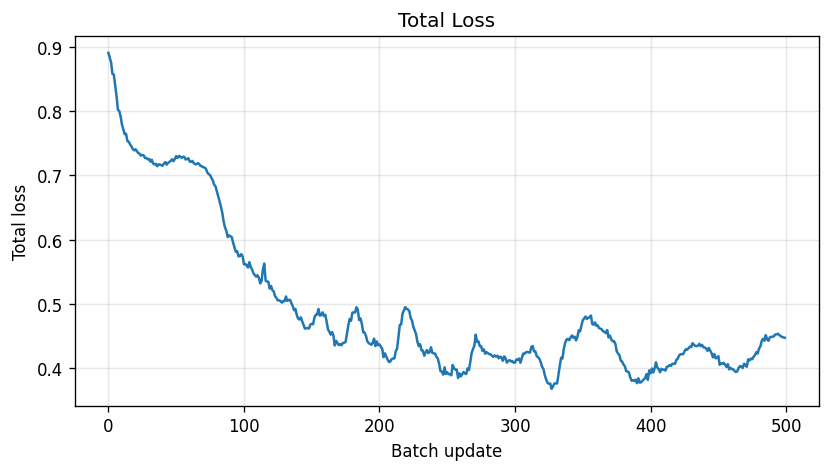

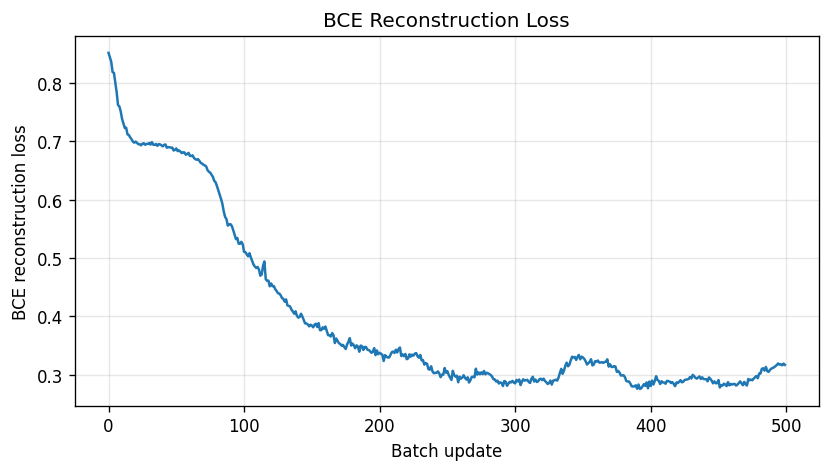

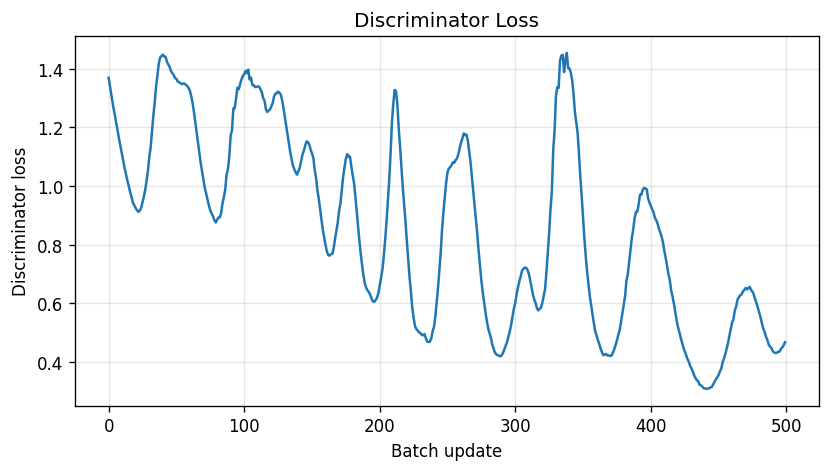

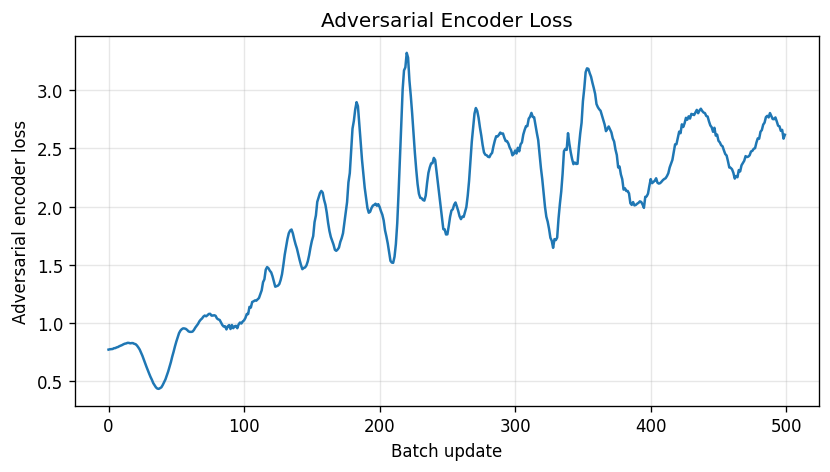

In [134]:
# ============================================================
# Separate training curves
# ============================================================

plt.figure(figsize=(8, 4))
plt.plot(history_empirical_prior["loss"])
plt.xlabel("Batch update")
plt.ylabel("Total loss")
plt.title("Total Loss")
plt.grid(True, alpha=0.3)
plt.show()

if "bce_loss" in history_empirical_prior:
    plt.figure(figsize=(8, 4))
    plt.plot(history_empirical_prior["bce_loss"])
    plt.xlabel("Batch update")
    plt.ylabel("BCE reconstruction loss")
    plt.title("BCE Reconstruction Loss")
    plt.grid(True, alpha=0.3)
    plt.show()

if "disc_loss" in history_empirical_prior:
    plt.figure(figsize=(8, 4))
    plt.plot(history_empirical_prior["disc_loss"])
    plt.xlabel("Batch update")
    plt.ylabel("Discriminator loss")
    plt.title("Discriminator Loss")
    plt.grid(True, alpha=0.3)
    plt.show()

if "adv_loss" in history_empirical_prior:
    plt.figure(figsize=(8, 4))
    plt.plot(history_empirical_prior["adv_loss"])
    plt.xlabel("Batch update")
    plt.ylabel("Adversarial encoder loss")
    plt.title("Adversarial Encoder Loss")
    plt.grid(True, alpha=0.3)
    plt.show()

In [135]:
model_with_empirical_prior.eval()

train_edges = cora_graph.train_edges.to(DEVICE)
edge_index = train_edges[:, :2].t().contiguous()
edge_type = train_edges[:, 2]
node_features = (
    cora_graph.node_features.to(DEVICE)
    if cora_graph.node_features is not None
    else None
)
with torch.no_grad():
    z, mu, log_sig = model_with_empirical_prior(
        edge_index,
        edge_type,
        node_features=node_features,
        num_nodes=cora_graph.num_nodes,
    )

z_cpu = z.detach().cpu()
#mu_cpu = mu.detach().cpu()
##log_sig_cpu = log_sig.detach().cpu()

latent_path = MODEL_DIR / "latent_data.pt"

torch.save(
    {
        "z": z_cpu,
        # "mu": mu_cpu,
        # "log_sig": log_sig_cpu,
        "train_edges": cora_graph.train_edges.cpu(),
        "val_edges": cora_graph.val_edges.cpu(),
        "test_edges": cora_graph.test_edges.cpu(),
        "node_features": (
            cora_graph.node_features.cpu()
            if cora_graph.node_features is not None
            else None
        ),
        "num_nodes": cora_graph.num_nodes,
        "num_relations": cora_graph.num_relations,
        "graph_name": cora_graph.name,
    },
    latent_path,
)

print(f"Saved final latents to {latent_path}")
print("z:", z_cpu.shape)
# print("mu:", mu_cpu.shape)
# print("log_sig:", log_sig_cpu.shape)


Saved final latents to /Users/adamabramowitz/Desktop/Everything_Coding/Math290/290-Final-Project/Detective_R-GCN/model/latent_data.pt
z: torch.Size([2708, 16])


z mean: -0.11655960977077484
z std: 2.0519444942474365
latents_2d range: [-5.985631 -5.562065] [8.619921 7.442971]


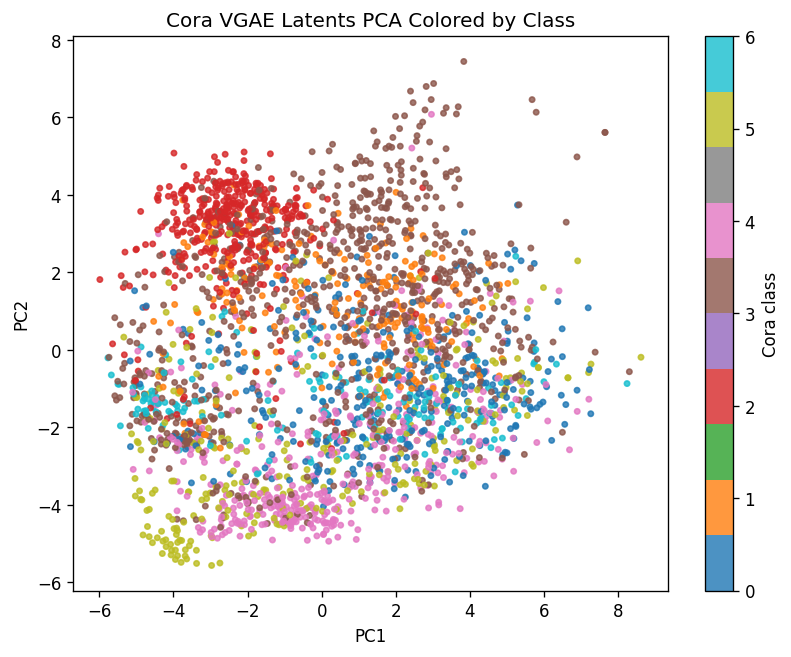

In [136]:
from sklearn.decomposition import PCA

latents = z_cpu.numpy()
latents_2d = PCA(n_components=2).fit_transform(latents)

print("z mean:", z_cpu.mean().item())
print("z std:", z_cpu.std().item())
print("latents_2d range:", latents_2d.min(axis=0), latents_2d.max(axis=0))

labels = cora_graph.node_labels.cpu().numpy()

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    latents_2d[:, 0],
    latents_2d[:, 1],
    c=labels,
    s=10,
    alpha=0.8,
    cmap="tab10",
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Cora VGAE Latents PCA Colored by Class")
plt.colorbar(scatter, label="Cora class")
plt.show()